In [1]:
import pandas as pd

df= pd.read_csv('../data/processed/maternal_health_risk_clean.csv')
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,36.666667,86,high risk
1,35,140,90,13.0,36.666667,70,high risk
2,29,90,70,8.0,37.777778,80,high risk
3,30,140,85,7.0,36.666667,70,high risk
4,35,120,60,6.1,36.666667,76,low risk


In [2]:
import sys
sys.path.append('..')
from src.preprocessing import crear_indicador_fiebre
df = crear_indicador_fiebre(df)
df[['BodyTemp', 'tiene_fiebre']].sample(5)

,BodyTemp,tiene_fiebre
687,36.666667,0
408,36.666667,0
309,36.666667,0
166,36.666667,0
63,36.666667,0


## Decisión: codificación del target

`RiskLevel` es ordinal por naturaleza (low < mid < high), pero el EDA mostró que las 
variables predictoras no respaldan un orden lineal limpio entre las clases: en varios 
paneles (`Age`, `DiastolicBP`, `BS`), "low risk" y "mid risk" se solapan considerablemente 
entre sí, mientras que "high risk" se separa con claridad — es decir, "mid risk" no se 
comporta como un punto intermedio equidistante entre las otras dos clases.

**Decisión:** se trata `RiskLevel` como clasificación multiclase con categorías 
independientes (no ordinal), usando las etiquetas de texto directamente como target — 
scikit-learn las codifica internamente. Se descarta una codificación ordinal simple 
(0/1/2) porque asumiría una relación lineal entre clases que el propio EDA no respalda.

**Limitación conocida:** esta decisión no aprovecha la información de orden real que sí 
existe entre las clases (un error "low → high" es clínicamente peor que "low → mid"). Un 
modelo de clasificación ordinal específico podría capturar esto mejor, pero se considera 
fuera del alcance de este proyecto.


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['RiskLevel'])
Y = df['RiskLevel']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42, stratify=Y)

print(X_train.shape, X_test.shape)
Y_train.value_counts(normalize=True)

(809, 7) (203, 7)


RiskLevel
low risk     0.399258
mid risk     0.332509
high risk    0.268232
Name: proportion, dtype: float64

In [4]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [5]:
Y_pred = modelo_rf.predict(X_test)

In [6]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

   high risk       0.95      0.95      0.95        55
    low risk       0.90      0.78      0.83        81
    mid risk       0.74      0.87      0.80        67

    accuracy                           0.85       203
   macro avg       0.86      0.86      0.86       203
weighted avg       0.86      0.85      0.85       203



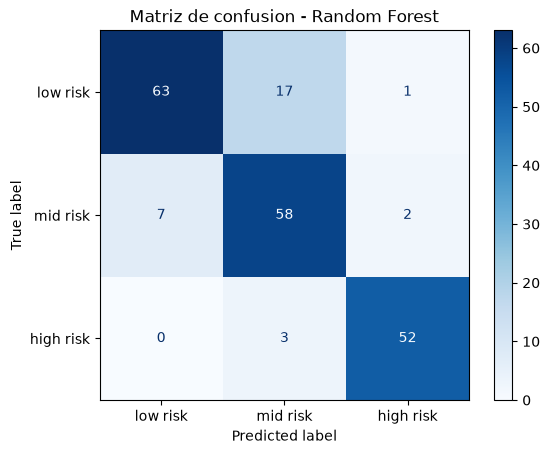

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    modelo_rf, X_test, Y_test, labels=['low risk', 'mid risk', 'high risk'],
    cmap='Blues'
)
plt.title('Matriz de confusion - Random Forest')
plt.show()

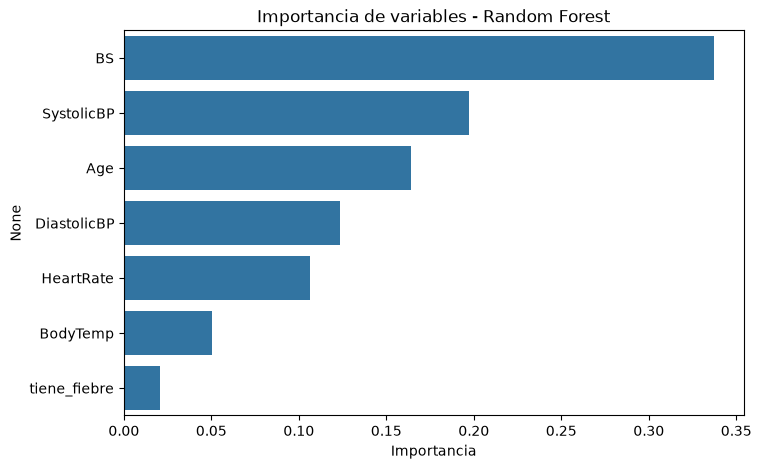

BS              0.337456
SystolicBP      0.197375
Age             0.163897
DiastolicBP     0.123665
HeartRate       0.106572
BodyTemp        0.050322
tiene_fiebre    0.020714
dtype: float64

In [8]:
import seaborn as sns
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia')
plt.show()

importancias

## Nota sobre importancia de variables y multicolinealidad

`BS` es la variable más importante (0.34), consistente con la hipótesis clínica de 
diabetes gestacional como factor de riesgo. `SystolicBP` (0.20) aparece con 
aproximadamente el doble de importancia que `DiastolicBP` (0.12), a pesar de que ambas 
mostraron una separación similar entre clases en el EDA y están fuertemente 
correlacionadas entre sí (r=0.79).

**Esto no significa que `DiastolicBP` sea clínicamente menos relevante.** Random Forest 
tolera bien la multicolinealidad en términos de capacidad predictiva (el modelo no pierde 
precisión por tener variables correlacionadas), pero la métrica de importancia sí puede 
verse distorsionada: cuando dos variables aportan información redundante, el algoritmo 
reparte la importancia de forma desigual entre ellas según decisiones acumuladas en cada 
árbol individual, sin que eso refleje necesariamente su relevancia clínica real. De hecho, 
existe una justificación clínica plausible para que ambas mantengan peso: la hipertensión 
sistólica y la diastólica no son intercambiables terapéuticamente (la primera suele ser 
más manejable farmacológicamente), por lo que se recomienda no descartar `DiastolicBP` 
del modelo pese a su menor importancia relativa aparente.


In [9]:
X_train = X_train.drop(columns=['BodyTemp'])
X_test = X_test.drop(columns=['BodyTemp'])
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, Y_train)

Y_pred = modelo_rf.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

   high risk       0.95      0.95      0.95        55
    low risk       0.89      0.77      0.82        81
    mid risk       0.73      0.85      0.79        67

    accuracy                           0.84       203
   macro avg       0.85      0.85      0.85       203
weighted avg       0.85      0.84      0.84       203



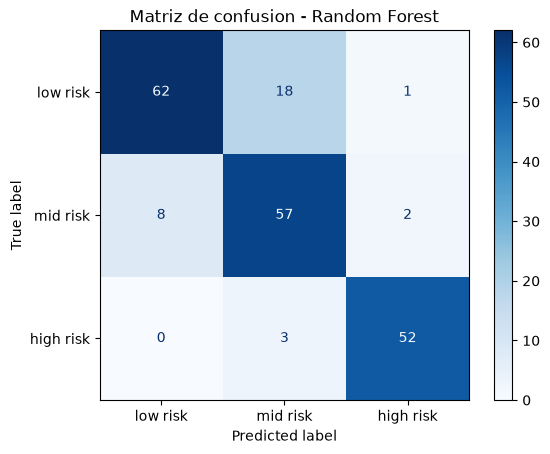

In [10]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf, X_test, Y_test, labels=['low risk', 'mid risk', 'high risk'],
    cmap='Blues'
)
plt.title('Matriz de confusion - Random Forest')
plt.show()

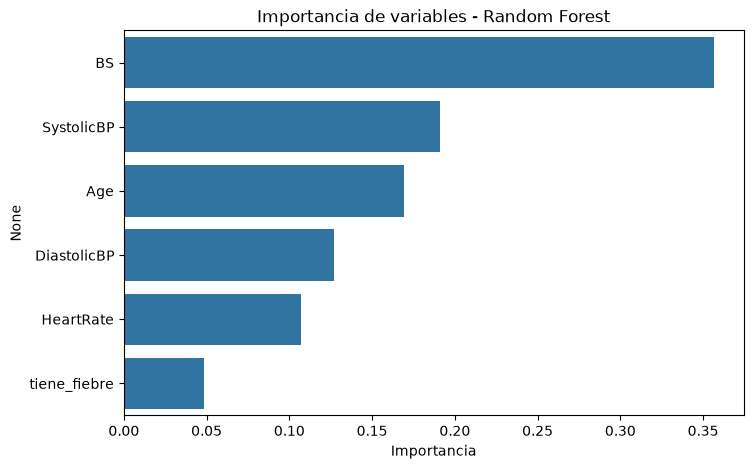

BS              0.356783
SystolicBP      0.191203
Age             0.169035
DiastolicBP     0.127163
HeartRate       0.107273
tiene_fiebre    0.048543
dtype: float64

In [11]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia')
plt.show()

importancias

## Confirmación: BodyTemp aporta poco valor predictivo

Al eliminar `BodyTemp` (conservando únicamente `tiene_fiebre` como su versión binaria), 
el accuracy del modelo pasó de 85% a 84% — una variación mínima, dentro del margen de 
ruido esperable con un test set de 203 muestras. El patrón de errores (concentrado en la 
confusión low↔mid, con high risk bien identificado) se mantuvo igual. Esto confirma 
empíricamente lo que sugería el EDA: la variable cruda de temperatura aportaba poca 
información adicional una vez capturado el indicador de fiebre.
